# YOLO pose filtering on the full dataset (no labels)

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

## Parameters

In [ ]:
PATH_MODEL = "./single_run.pt"
PATH_IMAGES = "../../databases/full databases/lepidoptera"

CSV_PATH = "./results_full.csv"

CONF_THRESHOLD = 0.5      # processable (>=) vs non processable (<)
IMG_CONF = 0.25           # detector confidence to keep a detection
DEVICE = None             # 0, "cpu", or None 

## Helper

In [ ]:
def image_confidence(kpts_conf):
    # mean confidence of all detected keypoints (0 if no detection)
    if kpts_conf.size == 0:
        return 0.0
    
    ## classic mean
    # return float(np.mean(kpts_conf))

    ## 

## Inference

In [5]:
import tqdm

def run_inference():
    model = YOLO(PATH_MODEL)
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    image_files = sorted(
        f for f in glob.glob(os.path.join(PATH_IMAGES, "*"))
        if f.lower().endswith(exts)
    )
    predict_kwargs = dict(conf=IMG_CONF, verbose=False)
    if DEVICE is not None:
        predict_kwargs["device"] = DEVICE

    rows = []
    for img_path in tqdm.tqdm(image_files):
        res = model.predict(img_path, **predict_kwargs)[0]
        if res.keypoints is not None and res.keypoints.data.shape[0] > 0:
            kconf = res.keypoints.data.cpu().numpy()[:, :, 2]
        else:
            kconf = np.zeros((0, 0))
        rows.append({"image": os.path.basename(img_path),
                     "confidence": image_confidence(kconf)})
    return pd.DataFrame(rows)

In [ ]:
if not os.path.exists(CSV_PATH):
    df = run_inference()
    df.to_csv(CSV_PATH, index=False)
    print("Inference done, saved:", CSV_PATH)
else:
    print("CSV already present, skipping inference:", CSV_PATH)

100%|██████████| 752/752 [05:32<00:00,  2.26it/s]

Inference done, saved: ./results_full.csv


## Load results

In [7]:
df = pd.read_csv(CSV_PATH)
print(len(df), "images")
df.head()

752 images


,image,confidence
0,EA1.0HJ.jpg,0.655332
1,EA1.0IU.jpg,0.634524
2,EA1.0OZ.jpg,0.633097
3,EA1.0P3.jpg,0.618634
4,EA1.0PX.jpg,0.652730


## Counts at the chosen threshold

In [ ]:
conf = df["confidence"].values
total = len(conf)
n_proc = int(np.sum(conf >= CONF_THRESHOLD))
n_non = int(np.sum(conf < CONF_THRESHOLD))
print(f"processable:     {n_proc} ({100 * n_proc / total:.1f}%)")
print(f"non processable: {n_non} ({100 * n_non / total:.1f}%)")

traitable:     738 (98.1%)
non traitable: 14 (1.9%)


## Class proportions vs confidence threshold (step 0.01)

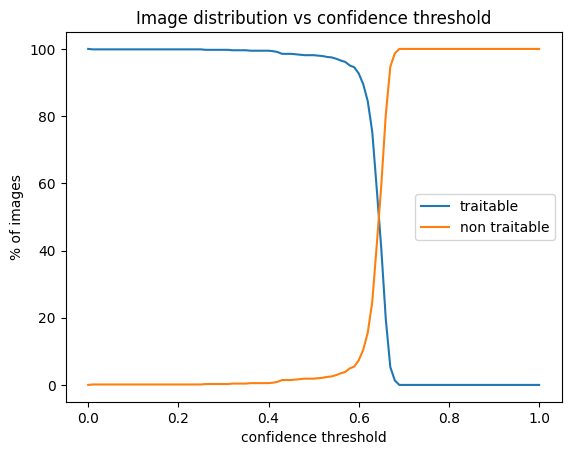

In [ ]:
thrs = np.round(np.arange(0.0, 1.0 + 1e-9, 0.01), 2)
pct_proc = np.array([100 * np.mean(conf >= t) for t in thrs])
pct_non = 100 - pct_proc

plt.figure()
plt.plot(thrs, pct_proc, label="processable")
plt.plot(thrs, pct_non, label="non processable")
plt.xlabel("confidence threshold")
plt.ylabel("% of images")
plt.title("Image distribution vs confidence threshold")
plt.legend()
plt.show()